# Skin Disease Detection using Deep Learning (ResNet50)

This notebook implements a deep learning model to classify skin diseases
from RGB images using PyTorch and transfer learning with ResNet50.

The model predicts five classes:
- Acne
- Chickenpox
- Fungal Infection
- Impetigo
- Psoriasis

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler

In [2]:
print(torch.cuda.is_available())

True


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
import os
print(os.getcwd())

/content


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
data_dir = "/content/drive/MyDrive/disease detection final dataset"

In [7]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Getting started.pdf', 'IMG-20220107-WA0024.jpg', 'Untitled presentation.gslides', 'Computer-Registers.pdf by Somyadeb Dutta(182).pdf', 'Colab Notebooks', 'IMG_20250423_201607.jpg', 'MAIN Resume (1).pdf', 'MAIN Resume.pdf', 'LR_assignment.xlsx', 'NIFTY 50-25-08-2024-to-25-08-2025.csv', 'binary_classification_training_dataset (1).csv', 'test_data.csv', 'ai_accuracy', 'binary_class_Colab.ipynb', 'cleaned_nifty50.csv', 'Resume_3.pdf', 'AMZN_stock_data.csv', 'multiclass_traindata_4sec (2).csv', 'multiclass_testdata_4sec (1).csv', 'multiclass', 'multi_class_classifier_code.ipynb', 'yolo', 'Resume (3).pdf', 'Resume (2).pdf', 'Resume.pdf', 'Resume (1) (1).pdf', 'Resume (1).pdf', 'Resume', 'multiclass classification', 'disease detection final dataset']


In [8]:
data_dir = "/content/drive/MyDrive/disease detection final dataset"

In [9]:
print(os.listdir(data_dir))

['psoriasis', 'impetigo', 'fungal infection', 'chicken pox', 'acne']


**Define Image Augmentation**

In [10]:
train_transform = transforms.Compose([

    transforms.Resize((256,256)),

    transforms.RandomResizedCrop(224),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

**Define Image Augmentation**

In [11]:
test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

**Load Dataset**

In [12]:
dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

In [13]:
print("Classes:", dataset.classes)
print("Total Images:", len(dataset))

Classes: ['acne', 'chicken pox', 'fungal infection', 'impetigo', 'psoriasis']
Total Images: 901


**Class Distribution**

In [14]:
from collections import Counter
print(Counter(dataset.targets))

Counter({4: 300, 0: 200, 1: 170, 3: 118, 2: 113})


In [15]:
print(dataset.classes)

['acne', 'chicken pox', 'fungal infection', 'impetigo', 'psoriasis']


In [16]:
print(dataset.class_to_idx)

{'acne': 0, 'chicken pox': 1, 'fungal infection': 2, 'impetigo': 3, 'psoriasis': 4}


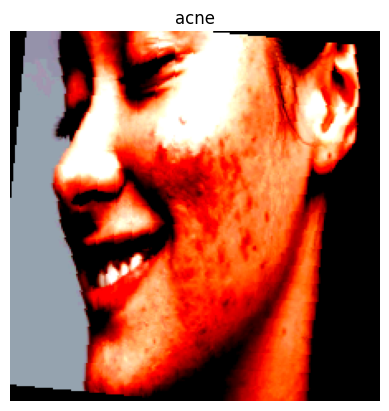

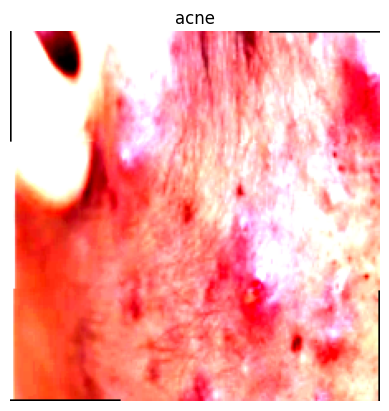

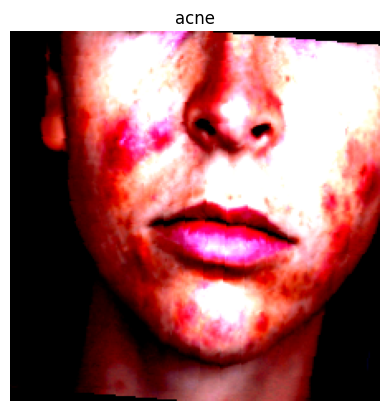

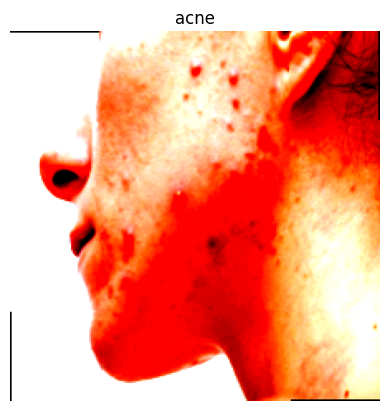

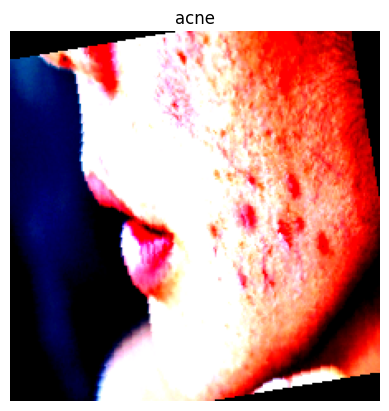

In [17]:
import matplotlib.pyplot as plt

for i in range(5):
    img, label = dataset[i]
    plt.imshow(img.permute(1,2,0))
    plt.title(dataset.classes[label])
    plt.axis("off")
    plt.show()

**Splitting dataset to 70-15-15**

In [18]:
dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

In [19]:
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

**Handle Class Imbalance (Weighted Sampler)**

In [20]:
train_targets = [dataset.targets[i] for i in train_dataset.indices]

class_sample_count = np.array(
    [train_targets.count(t) for t in np.unique(train_targets)]
)

weights = 1. / class_sample_count

samples_weight = np.array([weights[t] for t in train_targets])

samples_weight = torch.from_numpy(samples_weight).double()

sampler = WeightedRandomSampler(
    samples_weight,
    len(samples_weight)
)

**Creating dataloaders**

In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

**Verify image shape**

In [22]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([32, 3, 224, 224])


In [23]:
print(labels)

tensor([3, 1, 3, 3, 1, 4, 0, 4, 4, 1, 3, 3, 2, 4, 1, 4, 0, 0, 0, 0, 0, 2, 3, 1,
        4, 1, 2, 2, 4, 2, 0, 2])


**Model Resnet50**

In [24]:
model = models.resnet50(pretrained=True)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features,5)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]


In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

**Training**

In [26]:
num_epochs = 15

for epoch in range(num_epochs):

    model.train()

    running_loss = 0

    for images,labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print("Epoch:",epoch+1,"Loss:",running_loss/len(train_loader))

Epoch: 1 Loss: 0.5339404307305813
Epoch: 2 Loss: 0.0366652553435415
Epoch: 3 Loss: 0.011789977783337235
Epoch: 4 Loss: 0.038235244748648256
Epoch: 5 Loss: 0.015062663867138327
Epoch: 6 Loss: 0.023589236894622445
Epoch: 7 Loss: 0.04411008203169331
Epoch: 8 Loss: 0.014250871911644935
Epoch: 9 Loss: 0.006895049949525856
Epoch: 10 Loss: 0.0024056844355072825
Epoch: 11 Loss: 0.009141796879703179
Epoch: 12 Loss: 0.0047541319581796415
Epoch: 13 Loss: 0.001724646522779949
Epoch: 14 Loss: 0.0017404446836735588
Epoch: 15 Loss: 0.001620070512581151


**Accuracy calculation**

In [27]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images,labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _,predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

print("Test Accuracy:",100*correct/total)

Test Accuracy: 99.26470588235294


**Saving Model**

In [36]:
import torch

torch.save({
    "model_state_dict": model.state_dict(),
    "classes": dataset.classes
}, "skin_disease_resnet50.pth")

print("Model saved successfully!")

Model saved successfully!


In [37]:
!ls

 acne_test.jpg	 fungal_infection.jpg   sample_data
 drive		'psoriasis test.jpg'    skin_disease_resnet50.pth


In [38]:
from google.colab import files
files.download("skin_disease_resnet50.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

**Confusion Matrix**

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

print(cm)

[[33  1  0  0  0]
 [ 0 29  0  0  0]
 [ 0  0 14  0  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 44]]


**Plot Confusion Matrix**

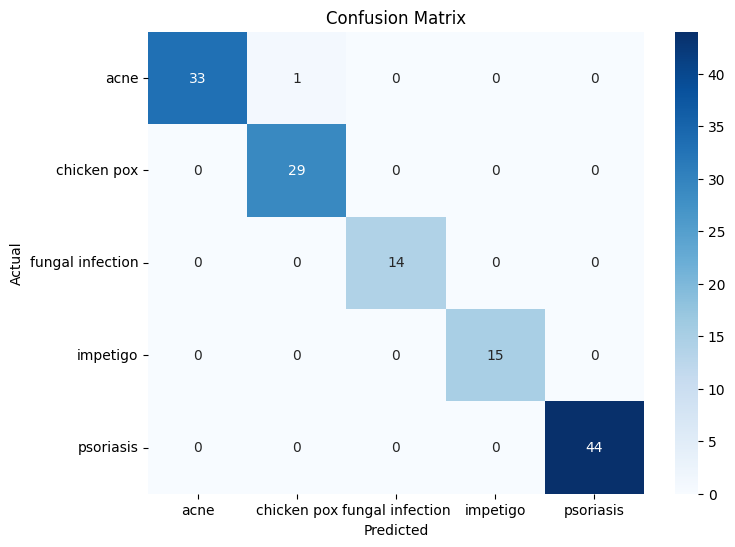

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = dataset.classes

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Metric Scores**

In [35]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=class_names))

                  precision    recall  f1-score   support

            acne       1.00      0.97      0.99        34
     chicken pox       0.97      1.00      0.98        29
fungal infection       1.00      1.00      1.00        14
        impetigo       1.00      1.00      1.00        15
       psoriasis       1.00      1.00      1.00        44

        accuracy                           0.99       136
       macro avg       0.99      0.99      0.99       136
    weighted avg       0.99      0.99      0.99       136



In [41]:
from google.colab import files
uploaded = files.upload()

**Single test image**

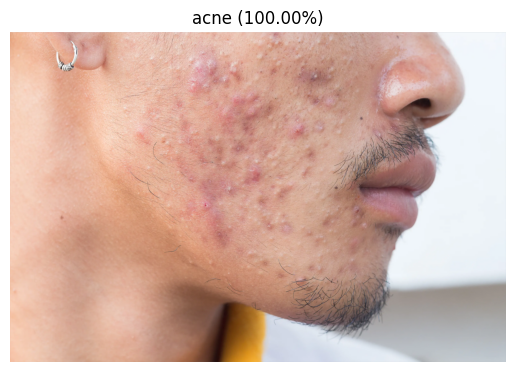

In [29]:
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt

img_path = "/content/acne_test.jpg"   # change file name

image = Image.open(img_path).convert("RGB")

input_img = test_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(input_img)
    probs = F.softmax(output, dim=1)
    _, pred = torch.max(output,1)

predicted_class = dataset.classes[pred.item()]
confidence = probs[0][pred.item()].item()

plt.imshow(image)
plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

**Test on multiple test image**

In [30]:
test_images = [
    "/content/acne_test.jpg",
    "/content/fungal_infection.jpg",
    "/content/psoriasis test.jpg"
]

for path in test_images:
    image = Image.open(path).convert("RGB")
    input_img = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        _, pred = torch.max(output,1)

    print(path, "→", dataset.classes[pred.item()])



/content/acne_test.jpg → acne
/content/fungal_infection.jpg → fungal infection
/content/psoriasis test.jpg → chicken pox


In [45]:
from google.colab import files
uploaded = files.upload()

Saving acne_test.jpg to acne_test (2).jpg
Saving fungal_infection.jpg to fungal_infection (2).jpg
Saving impetigo_test.jpg to impetigo_test (1).jpg


**Multiple test images with accuracy plots**

/content/acne_test.jpg
Predicted: acne
Actual: acne
Confidence: 100.00%



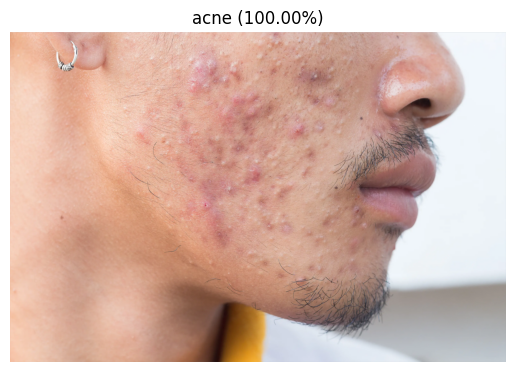

/content/fungal_infection.jpg
Predicted: fungal infection
Actual: fungal infection
Confidence: 99.99%



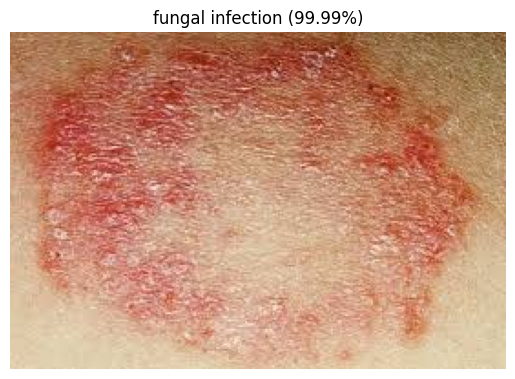

/content/impetigo_test.jpg
Predicted: impetigo
Actual: impetigo
Confidence: 99.97%



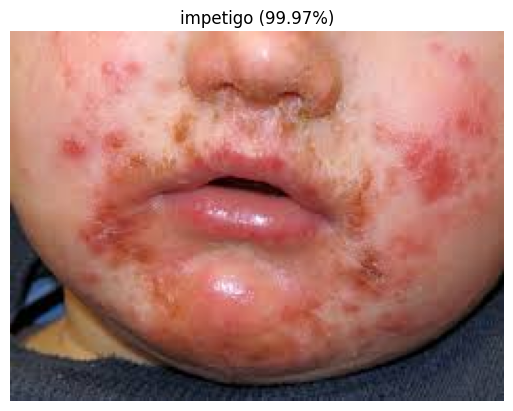

Overall Accuracy on Test Images: 100.00%


In [44]:
from PIL import Image
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

test_images = [
    "/content/acne_test.jpg",
    "/content/fungal_infection.jpg",
    "/content/impetigo_test.jpg"
]

true_labels = [
    "acne",
    "fungal infection",
    "impetigo"
]

correct = 0
total = len(test_images)

for i, path in enumerate(test_images):

    image = Image.open(path).convert("RGB")
    input_img = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_img)
        probs = F.softmax(output, dim=1)
        _, pred = torch.max(output, 1)

    predicted_class = dataset.classes[pred.item()]
    confidence = probs[0][pred.item()].item()
    actual_class = true_labels[i]

    # print result
    print(f"{path}")
    print(f"Predicted: {predicted_class}")
    print(f"Actual: {actual_class}")
    print(f"Confidence: {confidence*100:.2f}%\n")

    # accuracy count
    if predicted_class == actual_class:
        correct += 1

    # show image
    plt.imshow(image)
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.axis("off")
    plt.show()

# overall accuracy
accuracy = (correct / total) * 100
print(f"Overall Accuracy on Test Images: {accuracy:.2f}%")